## Import Libraries
- pandas: used to organize and clean the dataset
- numpy: used for numerical values and the logistic regression visualization
- matplotlib: used to create graphs
- scikit-learn: used to split the data, train the models, and evaluate their performace

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


## Load the Dataset
The dataset contains makeup foundation shades from multiple brands. Each row represents an individual shade. Because my research question is about whether a brand's overall shade range is inclusive, I will later combine the individual shade rows into one row per brand.

In [36]:
df = pd.read_csv("shades.csv")

print("Rows and columns:", df.shape)
display(df.head())


Rows and columns: (625, 10)


,brand,brand_short,product,product_short,hex,H,S,V,L,group
0,Maybelline,mb,Fit Me,fmf,f3cfb3,26.0,0.26,0.95,86,2
1,Maybelline,mb,Fit Me,fmf,ffe3c2,32.0,0.24,1.00,92,2
2,Maybelline,mb,Fit Me,fmf,ffe0cd,23.0,0.20,1.00,91,2
3,Maybelline,mb,Fit Me,fmf,ffd3be,19.0,0.25,1.00,88,2
4,Maybelline,mb,Fit Me,fmf,bd9584,18.0,0.30,0.74,65,2


## Clean the Data
Before modeling, I remove rows that are missing a brand name or lightness value (L). I also remove exact duplicate shades. I do this because missing or duplicated rows could distort the statistics that are calculated later.

In [21]:
df = df.dropna(subset=["brand", "L"]).copy()

df = df.drop_duplicates(
    subset=["brand", "product", "hex"]
).copy()

print("Cleaned rows:", len(df))


Cleaned rows: 621


**Creating the Target Variable** 
We need an "inclusive" label since the dataset doesn't have one. 
 
A "deeper shade" is defined as one in the darkest one-third based on its lightness value (L). A brand is labeled "Inclusive" if its percentage of deeper shades is above the median of all brands. 
 
**Defining a Deeper Shade** 
A deeper shade has a lightness value (L) in the darkest one-third of shades. Lower L values indicate darker shades.



In [22]:
deep_cutoff = df["L"].quantile(1/3)

df["deep_shade"] = (
    df["L"] <= deep_cutoff
).astype(int)

print("Deep shade lightness cutoff:", deep_cutoff)


Deep shade lightness cutoff: 61.0


## Change the Unit of Analysis to One Brand per Row
For each brand, I calculate:
- number of shades
- minimum lightness
- maximum lightness
- standard deviation of lightness
- overall lightness range
- share of shades classified as deep

These describe how braod and varied each brand's shade lineup is.

In [23]:
brand_df = df.groupby("brand").agg(
    brand_group=("group", "first"),
    shade_count=("L", "count"),
    lightness_min=("L", "min"),
    lightness_max=("L", "max"),
    lightness_std=("L", "std"),
    deep_shade_share=("deep_shade", "mean")
).reset_index()

brand_df["lightness_std"] = (
    brand_df["lightness_std"].fillna(0)
)

brand_df["lightness_range"] = (
    brand_df["lightness_max"]
    - brand_df["lightness_min"]
)

display(brand_df.head())
print("Number of brands:", len(brand_df))


,brand,brand_group,shade_count,lightness_min,lightness_max,lightness_std,deep_shade_share,lightness_range
0,Addiction,6,17,60,90,9.439046,0.117647,30
1,Beauty Bakerie,3,29,22,94,23.044346,0.379310,72
2,Bharat & Doris,7,7,68,83,5.507571,0.000000,15
3,Black Opal,3,12,23,65,14.531835,0.916667,42
4,Black Up,3,18,16,86,20.153009,0.666667,70


Number of brands: 36


## Create the Target Variable
My target variable is inclusive_range

I used a project defined proxy:
- 0 = not inclusive
- 1 = inclusive

A brand is labeled inclusive if its share of deeper shades is above the median share across all brands

This is a simplified definition for the project and should not be treated as a universal measure of inclusivity.

In [24]:
inclusive_cutoff = (
    brand_df["deep_shade_share"].median()
)

brand_df["inclusive_range"] = (
    brand_df["deep_shade_share"]
    > inclusive_cutoff
).astype(int)

print("0 = Not Inclusive")
print("1 = Inclusive")
print()
print(brand_df["inclusive_range"].value_counts())


0 = Not Inclusive
1 = Inclusive

inclusive_range
0    18
1    18
Name: count, dtype: int64


## Explore the Target Distribution
Before training the models, I check how many brands fall into each class.

This helps me see whether the dataset is balanced or whether one class appears much more often than the other. A strong class imbalance could affect the model's accuracy and other evaluation metrics

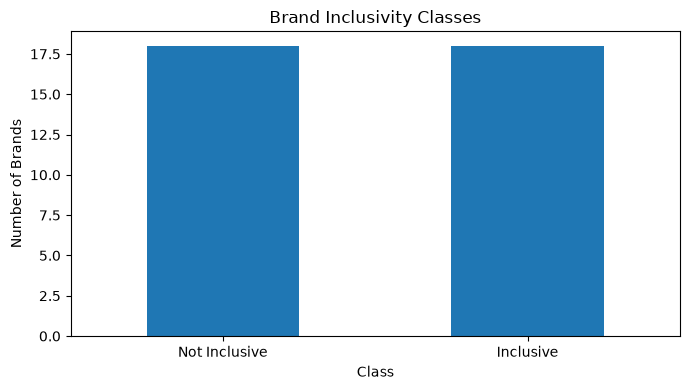

In [25]:
brand_df["inclusive_range"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Brand Inclusivity Classes")
plt.xlabel("Class")
plt.ylabel("Number of Brands")
plt.xticks(
    [0, 1],
    ["Not Inclusive", "Inclusive"],
    rotation=0
)

plt.tight_layout()
plt.show()


## Choose the Features
The features used to predict inclusivity are:
- brand group
- shade count
- minimum lightness
- maximum lightness
- lightness range
- lightness standard deviation

Because brand_group is categorical, I convert it into numeric dummy variables using pd.get_dummies().

In [26]:
features = [
    "brand_group",
    "shade_count",
    "lightness_min",
    "lightness_max",
    "lightness_range",
    "lightness_std"
]

X = brand_df[features]
y = brand_df["inclusive_range"]

X = pd.get_dummies(
    X,
    columns=["brand_group"],
    drop_first=True
)

display(X.head())


,shade_count,lightness_min,lightness_max,lightness_range,lightness_std,brand_group_1,brand_group_2,brand_group_3,brand_group_4,brand_group_5,brand_group_6,brand_group_7
0,17,60,90,30,9.439046,False,False,False,False,False,True,False
1,29,22,94,72,23.044346,False,False,True,False,False,False,False
2,7,68,83,15,5.507571,False,False,False,False,False,False,True
3,12,23,65,42,14.531835,False,False,True,False,False,False,False
4,18,16,86,70,20.153009,False,False,True,False,False,False,False


## Split the Data into Training and Testing Sets
I can evaluate how well the model works on brands it did not train on.

I use stratify=y so both the training and test sets keep a similar balance of Inclusive and Not Inclusive brands.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 27
Testing rows: 9


## Create a Baseline Model
Before training the machine-learning models, I create a simple baseline.

The baseline always predicts the most common class. This gives me a basic score that Logistic Regression and Random Forest should outperform if they are learning useful patterns.

In [28]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Baseline Accuracy:",
      round(
          accuracy_score(
              y_test,
              baseline_predictions
          ),
          3
      ))


Baseline Accuracy: 0.444


## Logistic Regression
Logistic Regression is appropriate because my target has two classes.
The model estimates the probability that a brand belongs to the Inclusive class based on the selected features.

I evaluate the model using Accuracy, Precision, Recall, and F1 Score.

In [29]:
# Logistic Regression

logreg = LogisticRegression(
    max_iter=1000
)

logreg.fit(X_train, y_train)

logreg_predictions = logreg.predict(X_test)

print("--- Logistic Regression ---")

print("Accuracy:",
      round(
          accuracy_score(
              y_test,
              logreg_predictions
          ),
          3
      ))

print("Precision:",
      round(
          precision_score(
              y_test,
              logreg_predictions,
              zero_division=0
          ),
          3
      ))

print("Recall:",
      round(
          recall_score(
              y_test,
              logreg_predictions,
              zero_division=0
          ),
          3
      ))

print("F1 Score:",
      round(
          f1_score(
              y_test,
              logreg_predictions,
              zero_division=0
          ),
          3
      ))

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        logreg_predictions
    )
)


--- Logistic Regression ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[5 0]
 [0 4]]


## Random Forest
Random Forest builds many decision trees and combines their predictions.

I use this model because it can capture more complicated relationships between the brand features than Logistic Regression.

I use the same evaluation metrics so the two models can be compared fairly.

In [30]:
# Random Forest

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

forest.fit(X_train, y_train)

forest_predictions = forest.predict(X_test)

print("--- Random Forest ---")

print("Accuracy:",
      round(
          accuracy_score(
              y_test,
              forest_predictions
          ),
          3
      ))

print("Precision:",
      round(
          precision_score(
              y_test,
              forest_predictions,
              zero_division=0
          ),
          3
      ))

print("Recall:",
      round(
          recall_score(
              y_test,
              forest_predictions,
              zero_division=0
          ),
          3
      ))

print("F1 Score:",
      round(
          f1_score(
              y_test,
              forest_predictions,
              zero_division=0
          ),
          3
      ))

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        forest_predictions
    )
)


--- Random Forest ---
Accuracy: 0.889
Precision: 0.8
Recall: 1.0
F1 Score: 0.889
Confusion Matrix:
[[4 1]
 [0 4]]


## Compare Model Performance
I compare the baseline, Logistic Regression, and Random Forest using Accuracy and F1 Score.

Accuracy tells me how often the model is correct overall.

F1 Score balances Precision and Recall, which is useful when I care about correctly identifying the Inclusive class without producing too many incorrect Inclusive predictions.

,Model,Accuracy,F1 Score
0,Baseline,0.444,0.615
1,Logistic Regression,1.000,1.000
2,Random Forest,0.889,0.889


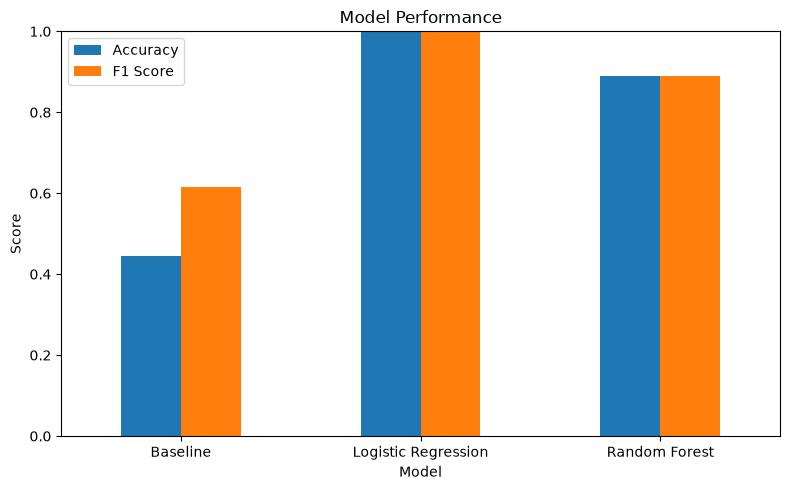

In [31]:
# Compare the three models

model_names = [
    "Baseline",
    "Logistic Regression",
    "Random Forest"
]

accuracy_scores = [
    accuracy_score(
        y_test,
        baseline_predictions
    ),
    accuracy_score(
        y_test,
        logreg_predictions
    ),
    accuracy_score(
        y_test,
        forest_predictions
    )
]

f1_scores = [
    f1_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    f1_score(
        y_test,
        logreg_predictions,
        zero_division=0
    ),
    f1_score(
        y_test,
        forest_predictions,
        zero_division=0
    )
]

results = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores,
    "F1 Score": f1_scores
})

display(results.round(3))

results.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Cross-Validation
A single train/test split can sometimes give unusually high or low results.

To get a more reliable estimate of model performance, I also use 5-fold cross-validation. This trains and evaluates each model several times on different sections of the data and then averages the F1 scores.

In [32]:
# Cross-validation

logreg_cv = cross_val_score(
    logreg,
    X,
    y,
    cv=5,
    scoring="f1"
)

forest_cv = cross_val_score(
    forest,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(
    "Logistic Regression Average F1:",
    round(logreg_cv.mean(), 3)
)

print(
    "Random Forest Average F1:",
    round(forest_cv.mean(), 3)
)


Logistic Regression Average F1: 0.971
Random Forest Average F1: 0.921


## Interpret Logistic Regression
This graph shows how the predicted probability of being Inclusive changes as the brand's lightness range changes while the other variables are held at typical values.

The dots represent the actual brand classes, while the curve shows the probability predicted by Logistic Regression.
The horizontal dashed line at 0.50 represents the usual classification cutoff.

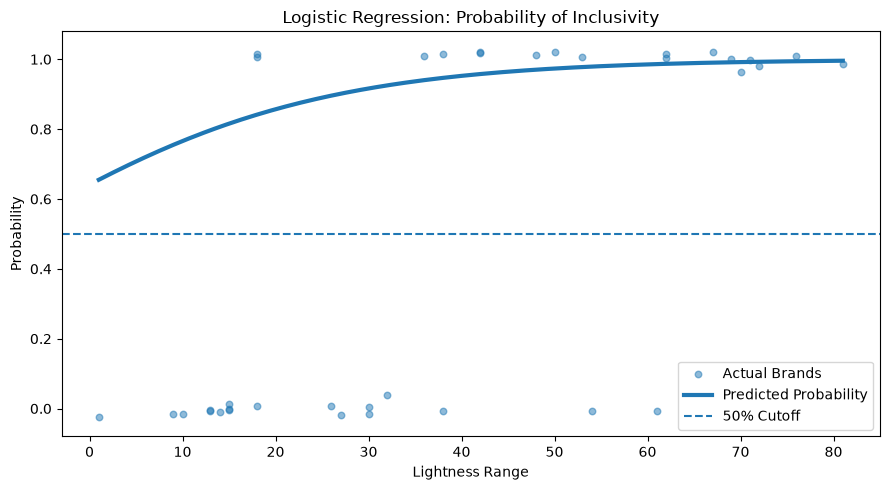

In [33]:
# Logistic Regression visualization

# Make values from the smallest to largest lightness range
range_values = np.linspace(
    X["lightness_range"].min(),
    X["lightness_range"].max(),
    200
)

# Start with typical values for all features
plot_data = pd.DataFrame(
    [X.median()] * 200
)

# Change only lightness_range
plot_data["lightness_range"] = range_values

# Get predicted probabilities
probabilities = (
    logreg.predict_proba(plot_data)[:, 1]
)

# Add a tiny amount of space between overlapping dots
rng = np.random.default_rng(42)

jitter = rng.normal(
    0,
    0.018,
    size=len(y)
)

plt.figure(figsize=(9, 5))

plt.scatter(
    X["lightness_range"],
    y + jitter,
    s=22,
    alpha=0.5,
    label="Actual Brands"
)

plt.plot(
    range_values,
    probabilities,
    linewidth=3,
    label="Predicted Probability"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% Cutoff"
)

plt.title(
    "Logistic Regression: Probability of Inclusivity"
)

plt.xlabel("Lightness Range")
plt.ylabel("Probability")
plt.ylim(-0.08, 1.08)
plt.legend()

plt.tight_layout()
plt.show()


## Interpret Random Forest
Random Forest feature importance shows which variables the model relied on most when making predictions.

A longer bar means that feature had a larger role in the model's decisions.
Feature importance shows influence inside the model, but it does not prove that a feature causes inclusivity.

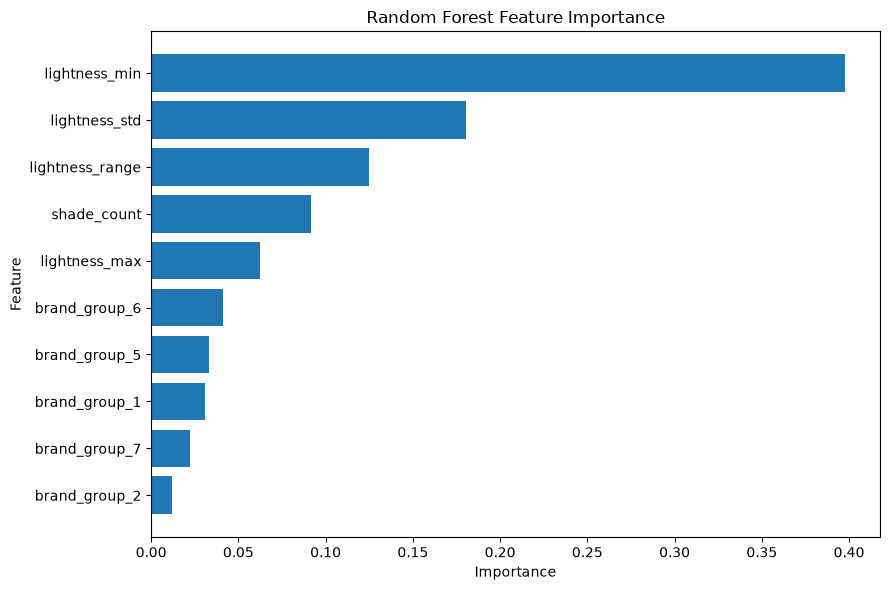

,Feature,Importance
1,lightness_min,0.398
4,lightness_std,0.180
3,lightness_range,0.125
0,shade_count,0.091
2,lightness_max,0.063
10,brand_group_6,0.041
9,brand_group_5,0.033
5,brand_group_1,0.031
11,brand_group_7,0.022
6,brand_group_2,0.012


In [34]:
# Random Forest feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

# Show only the 10 most important features
importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

display(
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .round(3)
)
